   type  n_agents  avg_speed  avg_decel
0     0       380   1.139820   0.000000
1     1         8   2.210734   0.250000
2     2         8   3.735626   0.000000
3     3       157   6.331613   7.210191
4     4         1   2.470593   0.000000
5     5         1   5.381609   0.000000
6     6         2   2.041217   0.500000
7     7         7   4.087275   0.285714


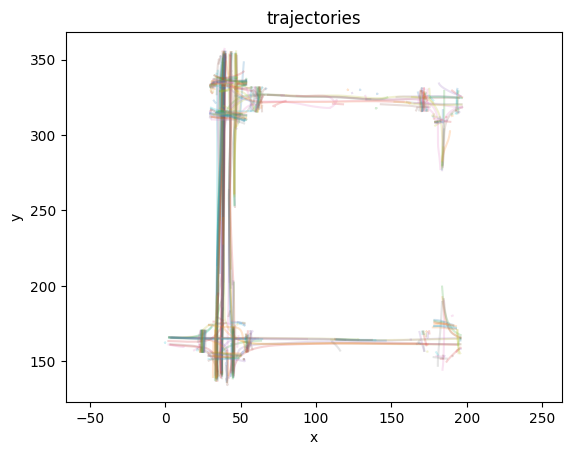

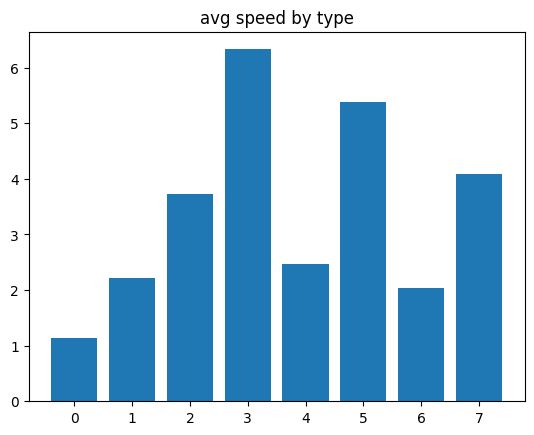

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load data
df = pd.read_csv("Transformed_TGSIM_Foggy_Bottom_200sec.csv")

# basic setup
df = df.sort_values(["id", "time"])

# speed magnitude
df["speed"] = np.sqrt(df["speed_kf_x"]**2 + df["speed_kf_y"]**2)

# acceleration from speed
df["dt"] = df.groupby("id")["time"].diff()
df["ds"] = df.groupby("id")["speed"].diff()
df["accel"] = df["ds"] / df["dt"]

# simple deceleration flag
df["decel"] = df["accel"] < -3

# summary by agent
agent_summary = df.groupby("id").agg(
    type=("type_most_common", "first"),
    mean_speed=("speed", "mean"),
    max_speed=("speed", "max"),
    decel_events=("decel", "sum")
).reset_index()

# summary by type
type_summary = agent_summary.groupby("type").agg(
    n_agents=("id", "count"),
    avg_speed=("mean_speed", "mean"),
    avg_decel=("decel_events", "mean")
).reset_index()

print(type_summary)

# plot trajectories
plt.figure()
for _, g in df.groupby("id"):
    plt.plot(g["xloc_kf"], g["yloc_kf"], alpha=0.2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("trajectories")
plt.axis("equal")
plt.show()

# speed comparison
plt.figure()
plt.bar(type_summary["type"], type_summary["avg_speed"])
plt.title("avg speed by type")
plt.show()